In [3]:
#import statements
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#file path
filepath="C:\\Users\\hp\\Downloads\\popular_cities_weather.csv"

In [5]:
#read_csv
df=pd.read_csv(filepath)

In [9]:
df.head()

,date,tavg,tmin,tmax,prcp,wspd,pres,tsun,city
0,2020-01-01 00:00:00,24.9,19.2,29.9,0.0,NaN,1013.4,13800.0,Mumbai
1,2020-02-01 00:00:00,27.3,21.0,32.6,0.0,NaN,1012.7,11220.0,Mumbai
2,2020-03-01 00:00:00,27.7,22.6,31.9,0.0,NaN,1011.2,12900.0,Mumbai
3,2020-04-01 00:00:00,30.2,26.4,33.9,0.0,NaN,1009.6,14220.0,Mumbai
4,2020-05-01 00:00:00,31.1,28.6,34.0,0.0,NaN,1007.3,15960.0,Mumbai


In [28]:
df.shape
print(df.shape)
df.tail()

(6912, 11)


,date,tavg,tmin,tmax,prcp,wspd,pres,tsun,city,temp_range,rainy_day
7051,2025-08-01 00:00:00,20.8,18.0,24.8,321.1,NaN,1007.4,NaN,Shimla,6.8,1
7052,2025-09-01 00:00:00,19.8,16.3,24.3,150.9,NaN,1009.4,NaN,Shimla,8.0,1
7053,2025-10-01 00:00:00,15.9,10.6,22.6,61.5,NaN,1015.1,NaN,Shimla,12.0,1
7054,2025-11-01 00:00:00,11.6,6.1,19.4,2.4,NaN,1017.8,NaN,Shimla,13.3,1
7055,2025-12-01 00:00:00,10.9,6.4,18.3,0.0,NaN,1017.9,NaN,Shimla,11.9,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    7056 non-null   object 
 1   tavg    6517 non-null   float64
 2   tmin    6452 non-null   float64
 3   tmax    6431 non-null   float64
 4   prcp    6126 non-null   float64
 5   wspd    0 non-null      float64
 6   pres    6434 non-null   float64
 7   tsun    2405 non-null   float64
 8   city    7056 non-null   object 
dtypes: float64(7), object(2)
memory usage: 496.3+ KB


In [12]:
df.duplicated().value_counts()

False    6912
True      144
Name: count, dtype: int64

In [13]:
df.columns

Index(['date', 'tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres', 'tsun', 'city'], dtype='object')

In [14]:
missing=df.isnull().sum()

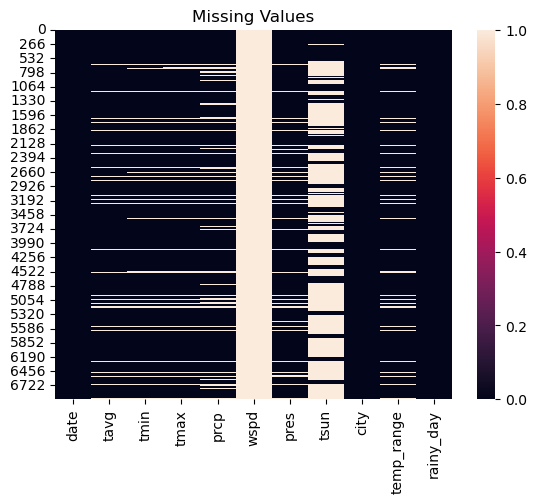

In [25]:
#Heaatmap
sns.heatmap(df.isnull())
plt.title("Missing Values")
plt.show()

In [15]:
#Temperature Range
df['temp_range'] = df['tmax'] - df['tmin']

#Rainy Day Flag
df['rainy_day'] = (df['prcp'] > 0).astype(int)

In [16]:
print(df.describe())

              tavg         tmin         tmax         prcp  wspd         pres  \
count  6517.000000  6452.000000  6431.000000  6126.000000   0.0  6434.000000   
mean     25.896179    20.843971    31.630944   117.887055   NaN  1008.847606   
std       5.220012     5.724433     5.035931   180.628768   NaN     5.308233   
min       0.600000    -4.500000     5.700000     0.000000   NaN   994.800000   
25%      23.300000    17.200000    29.300000     3.000000   NaN  1004.400000   
50%      27.100000    22.600000    32.000000    45.000000   NaN  1009.200000   
75%      29.500000    25.300000    34.700000   169.500000   NaN  1013.300000   
max      36.600000    31.000000    44.000000  1768.900000   NaN  1025.900000   

               tsun   temp_range    rainy_day  
count   2405.000000  6426.000000  7056.000000  
mean   10584.997921    10.793666     0.743481  
std     3864.452460     3.289823     0.436743  
min     1020.000000     2.900000     0.000000  
25%     7680.000000     8.100000     0.

In [17]:
df=df.drop_duplicates()

In [18]:
print(df['city'].value_counts())

city
Mumbai             72
Delhi              72
Durgapur           72
Dehradun           72
Bhavnagar          72
                   ..
Vasai-Virar        72
Kalyan-Dombivli    72
Meerut             72
Patiala            72
Shimla             72
Name: count, Length: 96, dtype: int64


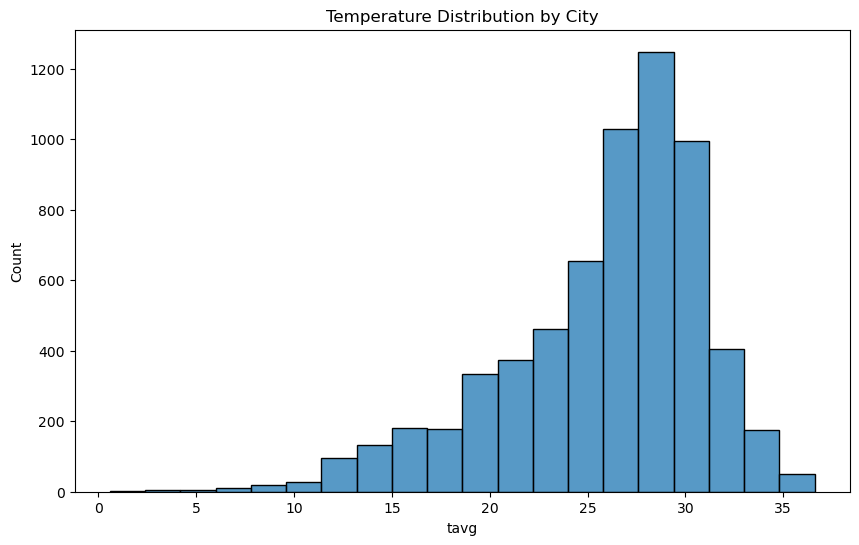

In [24]:
#Histogram
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='tavg',
    bins=20
)

plt.title("Temperature Distribution by City")

plt.show()

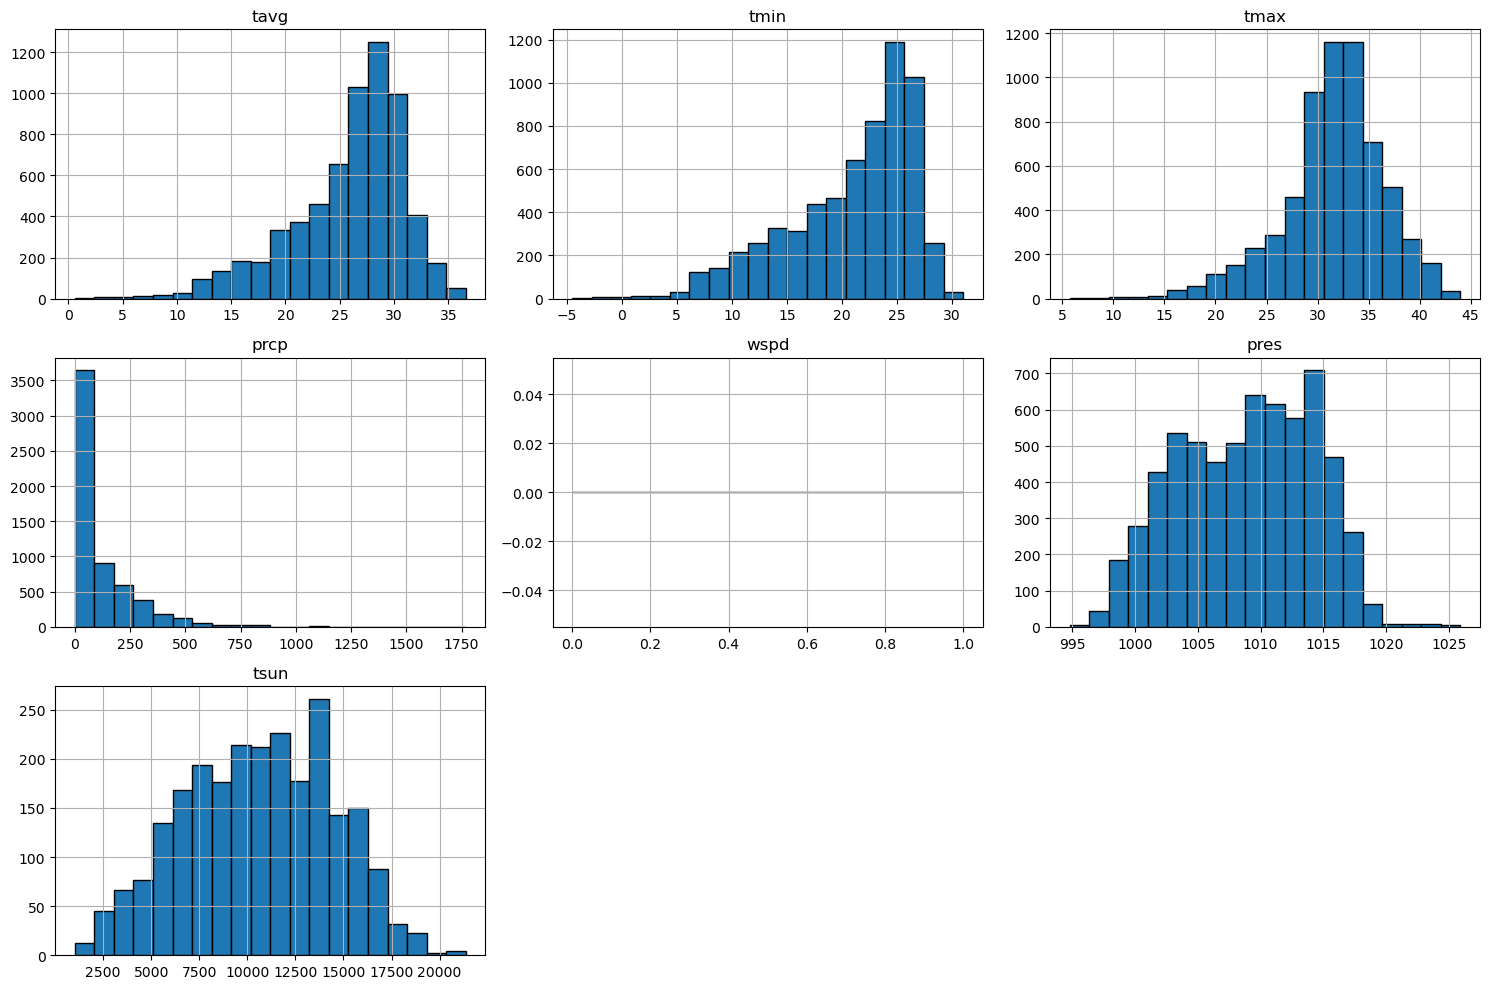

In [23]:
#To observe Rainfall outliers, skewness, temperature and unusual values
num_cols = ['tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres', 'tsun']

df[num_cols].hist(
    figsize=(15,10),
    bins=20,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

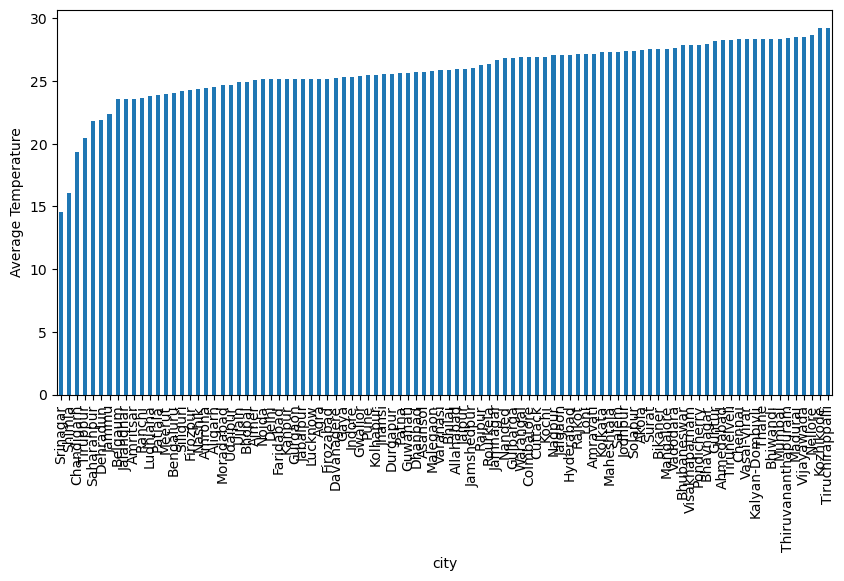

In [41]:
#Average Temperature in City
city_temp = df.groupby('city')['tavg'].mean().sort_values()

city_temp.plot(kind='bar', figsize=(10,5))
plt.ylabel("Average Temperature")
plt.show()

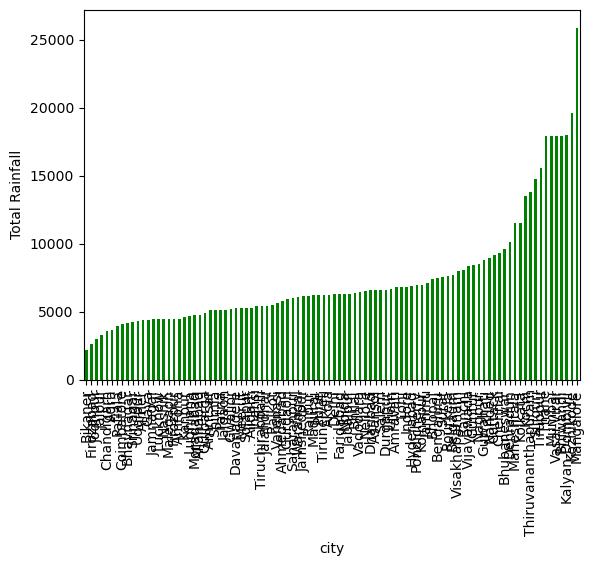

In [43]:
#Total Rainfall by city
city_rain = df.groupby('city')['prcp'].sum().sort_values()

city_rain.plot(kind='bar', color='green')
plt.ylabel("Total Rainfall")
plt.show()

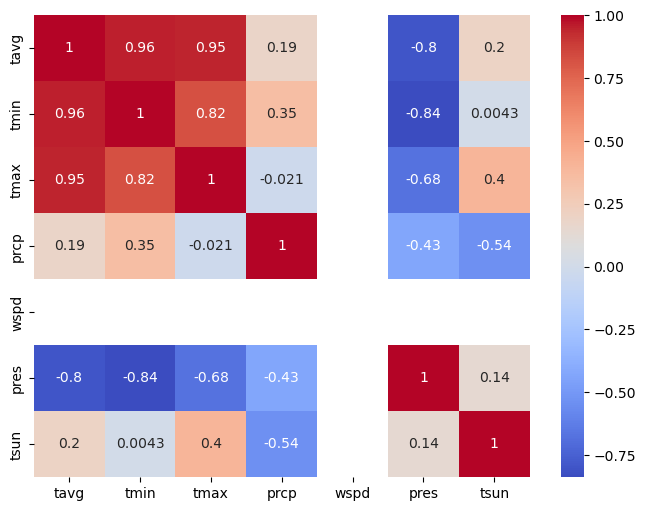

In [44]:
#Pressure Vs Temperature - Correlation Analysis
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [45]:
#highest Rainfall
df.nlargest(10, 'prcp')[['date', 'city', 'prcp']]

,date,city,prcp
42,2023-07-01 00:00:00,Mumbai,1768.9
1122,2023-07-01 00:00:00,Thane,1768.9
2058,2023-07-01 00:00:00,Kalyan-Dombivli,1768.9
2130,2023-07-01 00:00:00,Vasai-Virar,1768.9
4074,2023-07-01 00:00:00,Bhiwandi,1768.9
6234,2023-07-01 00:00:00,Mangalore,1689.0
54,2024-07-01 00:00:00,Mumbai,1663.8
1134,2024-07-01 00:00:00,Thane,1663.8
2070,2024-07-01 00:00:00,Kalyan-Dombivli,1663.8
2142,2024-07-01 00:00:00,Vasai-Virar,1663.8


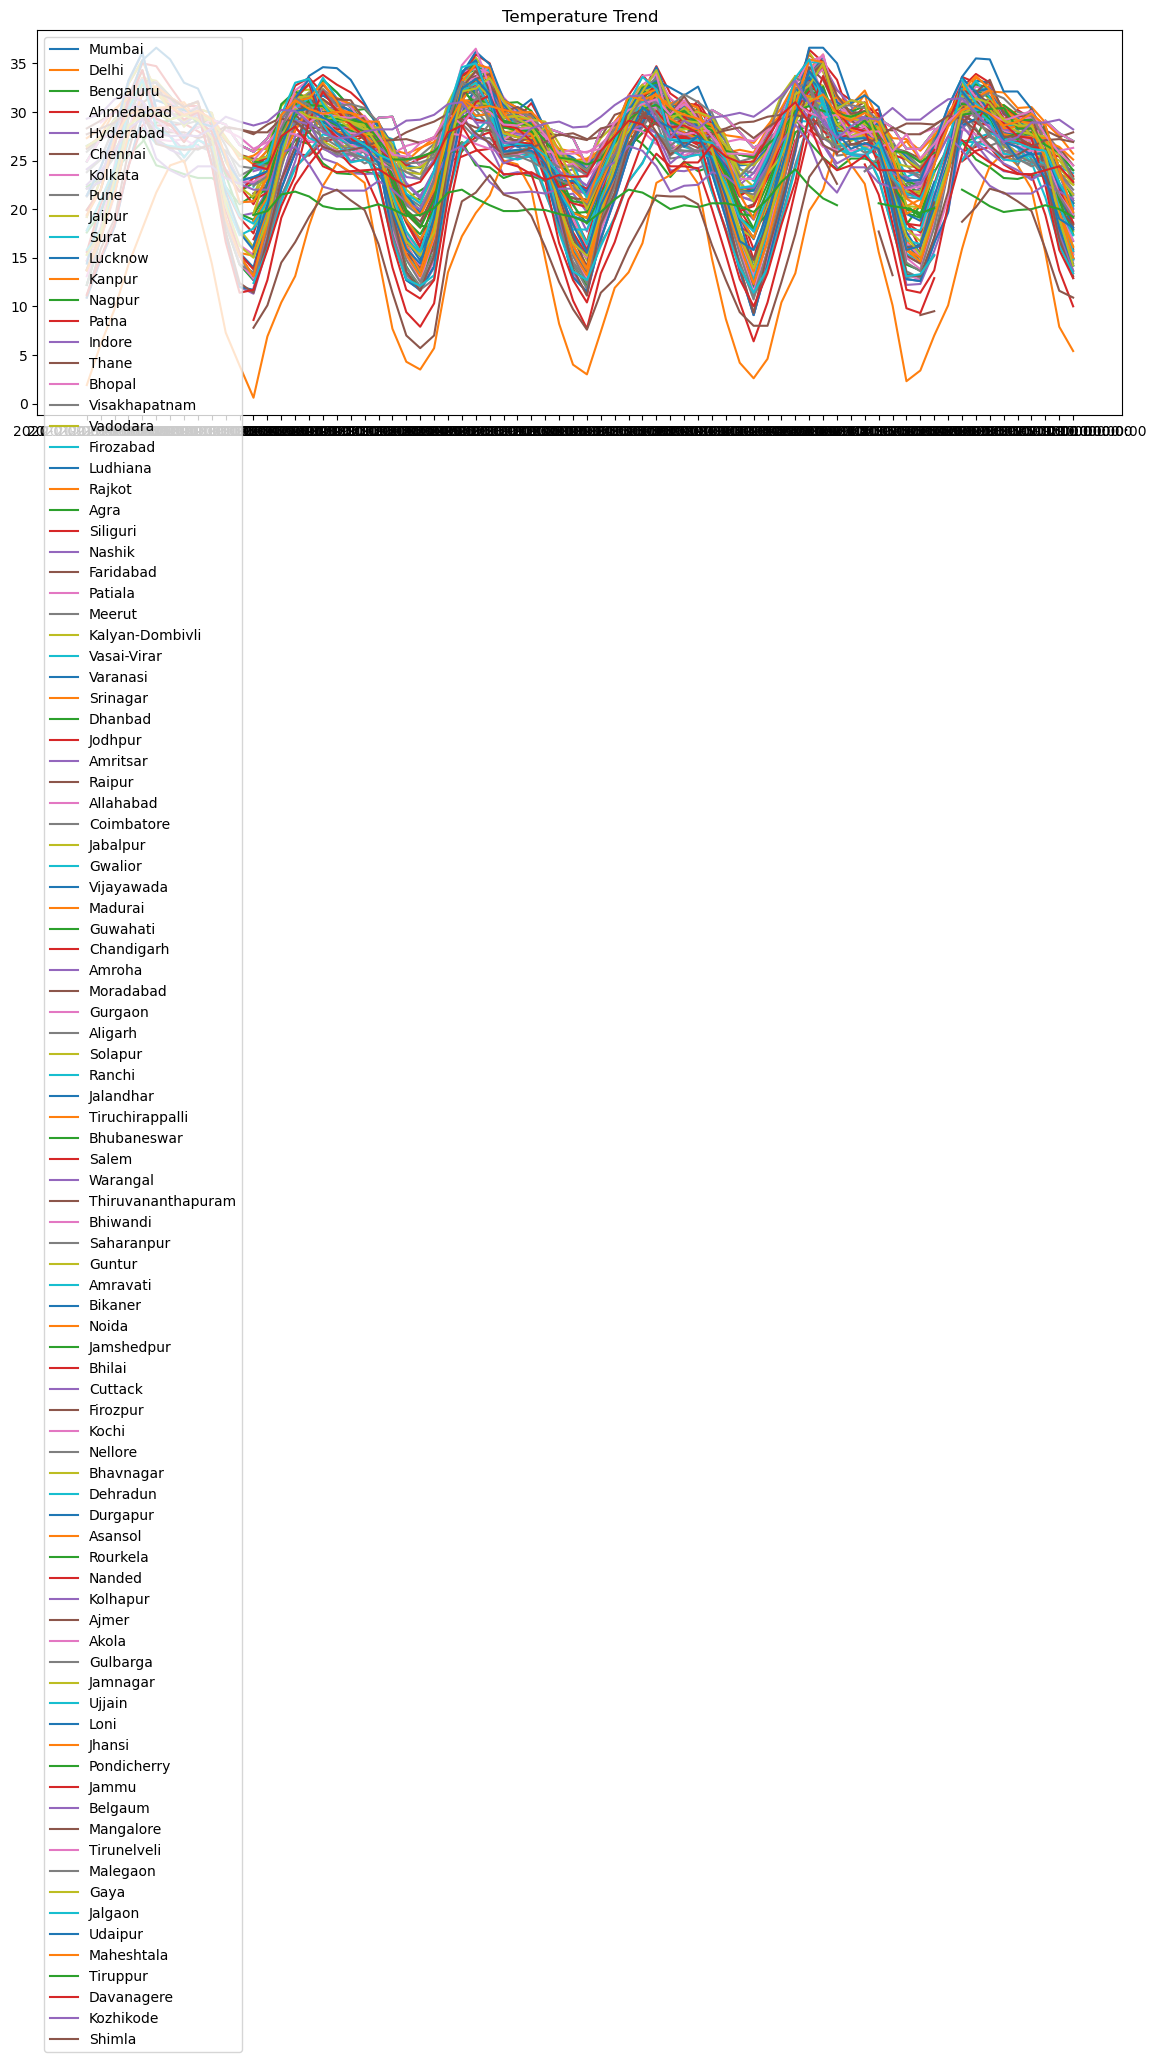

In [27]:
#Time Series line plot
plt.figure(figsize=(14,5))

for city in df['city'].unique():
    city_data = df[df['city'] == city]
    plt.plot(city_data['date'], city_data['tavg'], label=city)

plt.legend()
plt.title("Temperature Trend")
plt.show()

In [46]:
#Hottest Days
df.nlargest(10, 'tmax')[['date', 'city', 'tmax']]

,date,city,tmax
4252,2020-05-01 00:00:00,Amravati,44.0
5476,2020-05-01 00:00:00,Akola,44.0
5764,2020-05-01 00:00:00,Loni,44.0
4348,2022-05-01 00:00:00,Bikaner,43.9
4372,2024-05-01 00:00:00,Bikaner,43.8
5499,2022-04-01 00:00:00,Akola,43.8
2428,2024-05-01 00:00:00,Jodhpur,43.5
868,2020-05-01 00:00:00,Nagpur,43.3
5260,2020-05-01 00:00:00,Nanded,43.3
5500,2022-05-01 00:00:00,Akola,43.3


In [48]:
print("----- WEATHER DATASET EDA SUMMARY -----")

# Hottest city
hottest_city = df.groupby('city')['tavg'].mean().idxmax()
highest_temp = df.groupby('city')['tavg'].mean().max()

print(f"\nHottest City: {hottest_city}")

# Rainiest city
rainiest_city = df.groupby('city')['prcp'].sum().idxmax()
max_rain = df.groupby('city')['prcp'].sum().max()

print(f"\nRainiest City: {rainiest_city}")
print(f"Total Rainfall: {max_rain:.2f}")

# Temperature range
df['temp_range'] = df['tmax'] - df['tmin']

print(f"\nAverage Temperature Range: {df['temp_range'].mean():.2f} °C")

# Correlation
corr = df[['tavg','tmin','tmax','prcp','wspd','pres','tsun']].corr()

print("\nCorrelation with Average Temperature:")
print(corr['tavg'].sort_values(ascending=False))

# Outliers
Q1 = df['prcp'].quantile(0.25)
Q3 = df['prcp'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['prcp'] < (Q1 - 1.5 * IQR)) |
    (df['prcp'] > (Q3 + 1.5 * IQR))
]

print(f"\nRainfall Outliers Detected: {outliers.shape[0]}")

print("\nEDA Completed Successfully.")

----- WEATHER DATASET EDA SUMMARY -----

Hottest City: Tiruchirappalli
Average Temperature: 29.22 °C

Rainiest City: Mangalore
Total Rainfall: 25894.00

Average Temperature Range: 10.79 °C

Correlation with Average Temperature:
tavg    1.000000
tmin    0.956806
tmax    0.946405
tsun    0.197525
prcp    0.187603
pres   -0.797500
wspd         NaN
Name: tavg, dtype: float64

Rainfall Outliers Detected: 332

EDA Completed Successfully.


In [49]:
from IPython.display import Markdown, display

summary = """
# Final Conclusion

- Temperature patterns vary significantly across cities.
- Rainfall is highly seasonal and skewed.
- Strong positive correlation exists between tavg, tmin, and tmax.
- Extreme rainfall events were detected as outliers.
- Sunshine duration decreases during rainy periods.
- Dataset is suitable for forecasting and climate analysis tasks.
"""

display(Markdown(summary))


# Final Conclusion

- Temperature patterns vary significantly across cities.
- Rainfall is highly seasonal and skewed.
- Strong positive correlation exists between tavg, tmin, and tmax.
- Extreme rainfall events were detected as outliers.
- Sunshine duration decreases during rainy periods.
- Dataset is suitable for forecasting and climate analysis tasks.
